In [ ]:
# dev_create_disturbance_landscape_code_november2025 
#
# Used to be called:  disturbance_uncertainty_november2025_v2.ipynb
#  This is where I prototyped everything needed to build the landscapes. 
#   Now, I'm putting them all together into the landscape_stack_builder.ipynb


In [1]:
# parameter file
disturbance_config_two_types = {
    "random": {
        "seed": None    # None = use time-based randomness
    },

    "types": {
        "type1": {
            "name": "Conifer",
            "proportion_of_patches": 0.6,   # ~60% of patches

            "initial_cover": {
                "target_mean": 0.92,        # mean ~92% cover
                "kappa": 25                 # tighter
            },

            "proportional_loss": {
                "mixture": {
                    "catastrophic_probability": 0.01,   # 1% of patches in disaster mode
                    "background_alpha": 0.3,
                    "background_beta": 8.0,
                    "catastrophic_alpha": 8.0,
                    "catastrophic_beta": 0.7
                }
            }
        },

        "type2": {
            "name": "Hardwood",
            "proportion_of_patches": 0.4,   # ~40% of patches

            "initial_cover": {
                "target_mean": 0.85,        # mean ~85% cover
                "kappa": 18
            },

            "proportional_loss": {
                "mixture": {
                    "catastrophic_probability": 0.02,   # slightly more vulnerable
                    "background_alpha": 0.4,
                    "background_beta": 6.0,
                    "catastrophic_alpha": 7.0,
                    "catastrophic_beta": 1.0
                }
            }
        }
    },

    "thresholds": {
        # disturbed if final_cover < this AND cover_loss > 0
        "final_cover_percent": 15.0
    },

    "raster": {
        "band": 1
    },

    "plotting": {
        "patch_cmap": "rainbow",
        "initial_cover_cmap": "Greens", 
        "proportional_loss_cmap": "Oranges",
        "loss_abs_cmap": "Reds", 
        "final_cover_cmap": "Blues",
        "disturbed_cmap": "Greys_r",
        "type_cmap": "tab10"
    },

    "simulation": {
        "max_retries": 10   # retries if we end up with disturbed_fraction == 0
    }
}


Mean initial cover: 89.48662134870203
Mean final cover: 84.87456614206197
Mean cover loss: 4.612055206640067
Disturbed fraction: 0.009334515541106349
Disturbed fraction (type 0): 0.004849072614862408
Disturbed fraction (type 1): 0.016335540838852098
Retries: 0


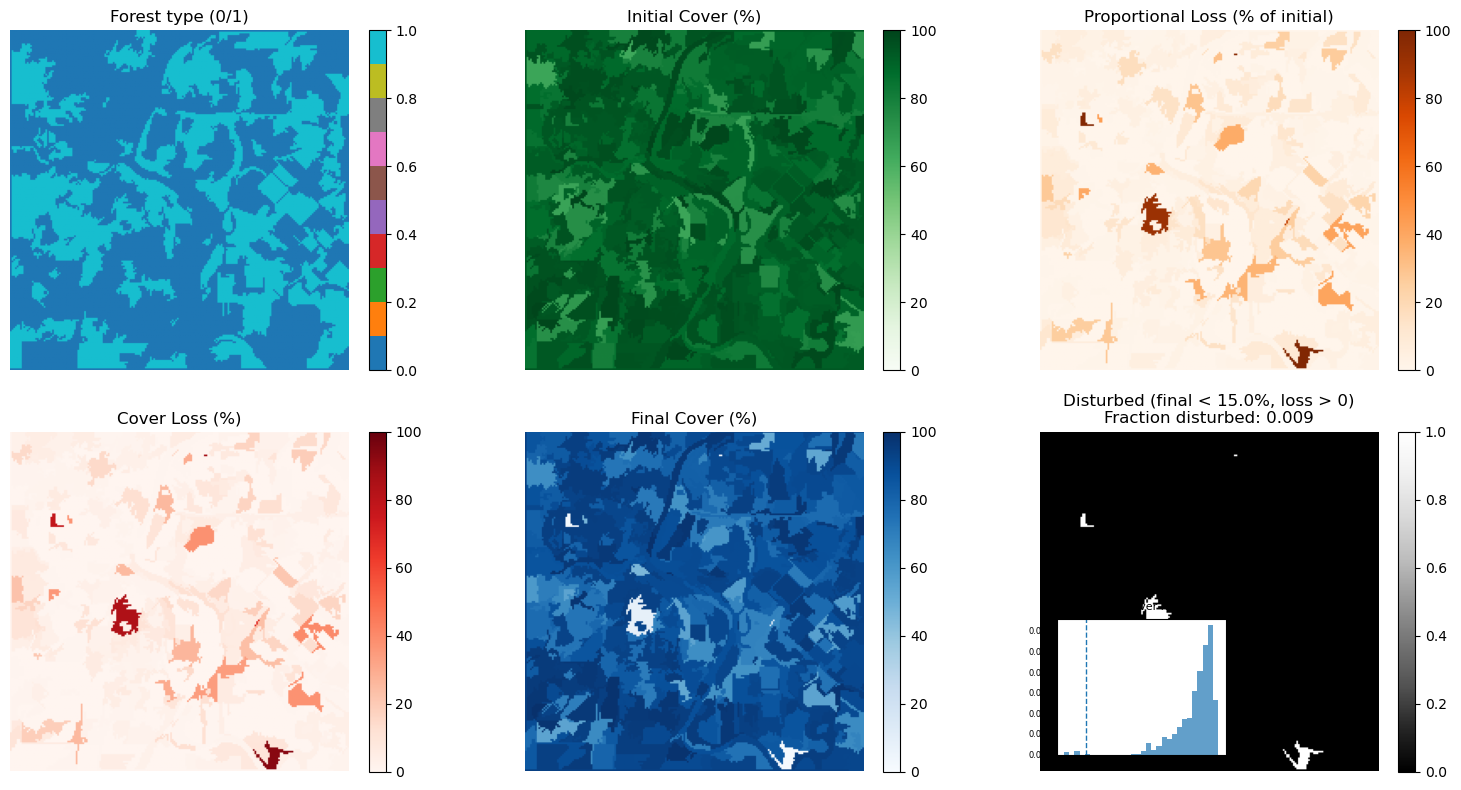

In [2]:
# implementation 

import os
from disturbance_landscape import DisturbanceLandscape


directory = "/Users/rkennedy/Dropbox/caol/code/_proj/dist_uncertainty/"
tif_path = os.path.join(directory, "downloaded_images/snic10.tif")

dist = DisturbanceLandscape(tif_path, disturbance_config_two_types)

print("Mean initial cover:", dist.mean_initial_cover)
print("Mean final cover:", dist.mean_final_cover)
print("Mean cover loss:", dist.mean_cover_loss)
print("Disturbed fraction:", dist.disturbed_fraction)
print("Disturbed fraction (type 0):", dist.disturbed_fraction_by_type(0))
print("Disturbed fraction (type 1):", dist.disturbed_fraction_by_type(1))
print("Retries:", dist.n_retries)

dist.plot_results(show_types=True)

In [ ]:
# now run the sensor field calculations.  Assumes that the
#  SensorField class is in the SensorField.py file


In [3]:
sensorA_config = {
    "signal_transform": {
        # global defaults; used if a type doesn't override
        "max_signal": 1000.0,
        "curve_k": 3.0
    },

    "gaussian_patch_noise": {
        # default per-type std proportion of range (if not overridden)
        "std_proportion_of_range": 0.0
    },

    "types": {
        "type1": {
            "signal_transform": {
                "max_signal": 900.0,
                "curve_k": 2.5
            },
            "gaussian_patch_noise": {
                "std_proportion_of_range": 0.02   # 2% of range for conifers
            }
        },
        "type2": {
            "signal_transform": {
                "max_signal": 1000.0,
                "curve_k": 3.5
            },
            "gaussian_patch_noise": {
                "std_proportion_of_range": 0.04   # 4% of range for hardwoods
            }
        }
    },

    "lowpass_filter": {
        "kernel_size": 3
    },

    "spatial_noise": {
        "spatial_autocorr_distance": 10.0,
        "amplitude_proportion_of_range": 0.1
    }
}


SensorA field shape: (202, 201)


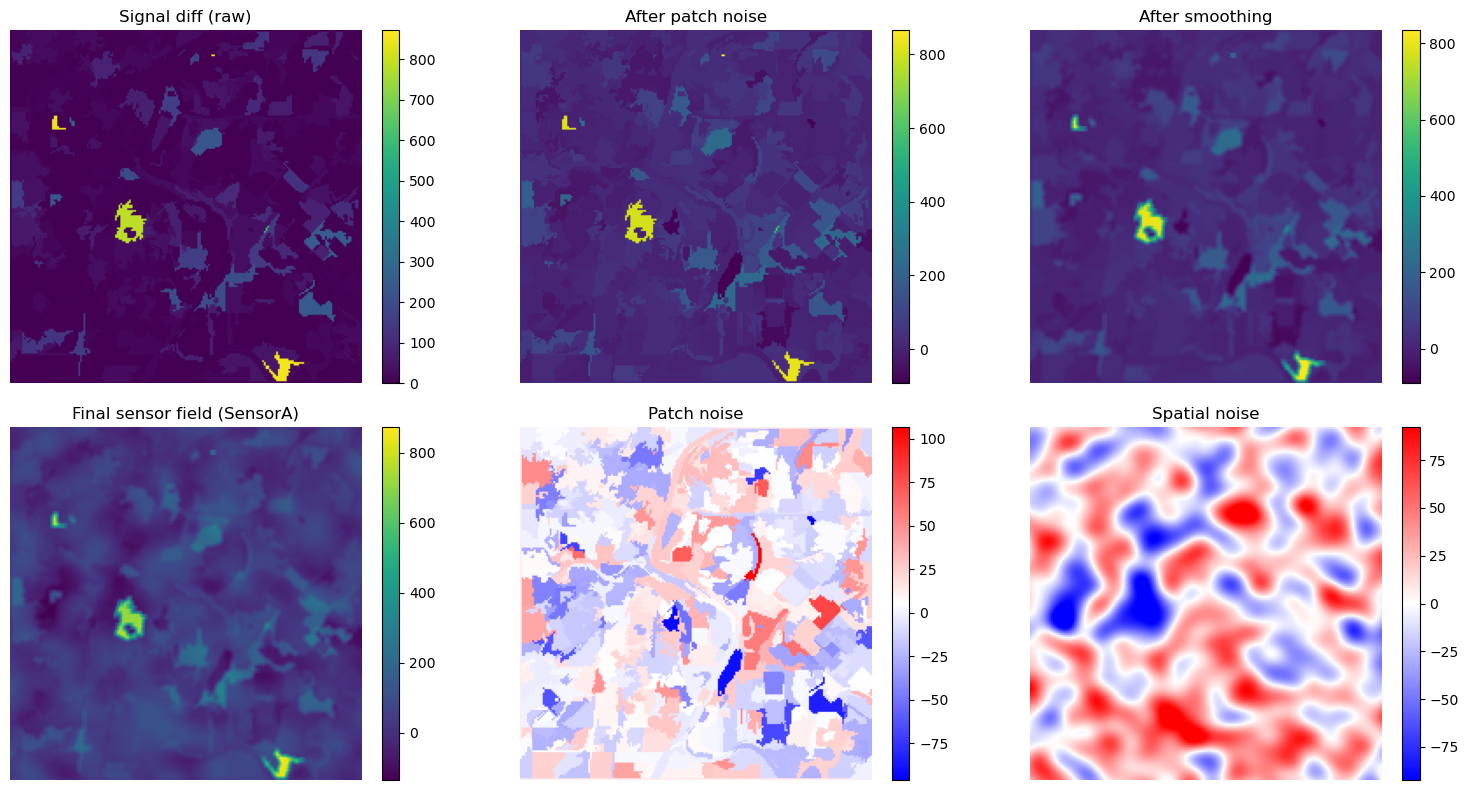

In [4]:
import importlib
from sensor_field import SensorField
import disturbance_helper_functions
#importlib.reload(disturbance_helper_functions)


sensorA = SensorField("SensorA", truth=dist, config=sensorA_config)

print("SensorA field shape:", sensorA.sensor_field.shape)
sensorA.plot_pipeline()


In [8]:
###  Interpreter configs

###  

interpreter_config = {
    "detection_curve": {
        # low sensitivity to subtle losses; strong response around ~20% cover loss
        "pivot_loss": 20.0,   # percent cover loss where p_detect ≈ 0.5
        "slope": 0.25         # logistic slope; larger = steeper
    },

    "definition_curve": {
        # interpreters more/less sharp around the forest threshold
        # threshold_override: None -> use DisturbanceLandscape threshold
        "threshold_override": None,
        "slope": 0.4
    },

    "gaussian_patch_noise": {
        # Gaussian patch offset: std_dev in percentage points
        # e.g., 8% => sigma = 0.08 in probability space
        "std_dev_percent": 20.0
    },

    "beta_patch_uncertainty": {
        # Beta(alpha, beta) for per-patch shrink scaler (0..1)
        # alpha<beta => more mass near 0 (small shrink) but still some big uncertainty
        "alpha": 3.0,
        "beta": 4.0
    },

    "lowpass_filter": {
        # edge effects / spatial blending
        "kernel_size": 3
    },

    "spatial_uncertainty": {
        # spatially correlated uncertainty field that shrinks towards 0.5
        "spatial_autocorr_distance": 8.0,   # in pixels
        "max_scaler": 0.3                  # max shrink strength (0..1)
    }
}

Example Gaussian patch offsets (percentage points):
{1: 1.665207047057618, 2: 13.27570389033132, 3: -11.559708946112526, 4: 38.04482004068808, 5: -14.695926533757756}
Example Beta scalers (shrink towards 50%):
{1: 0.6787624567859233, 2: 0.32557990759907807, 3: 0.15754346839633754, 4: 0.4747904183264129, 5: 0.5043259884268582}


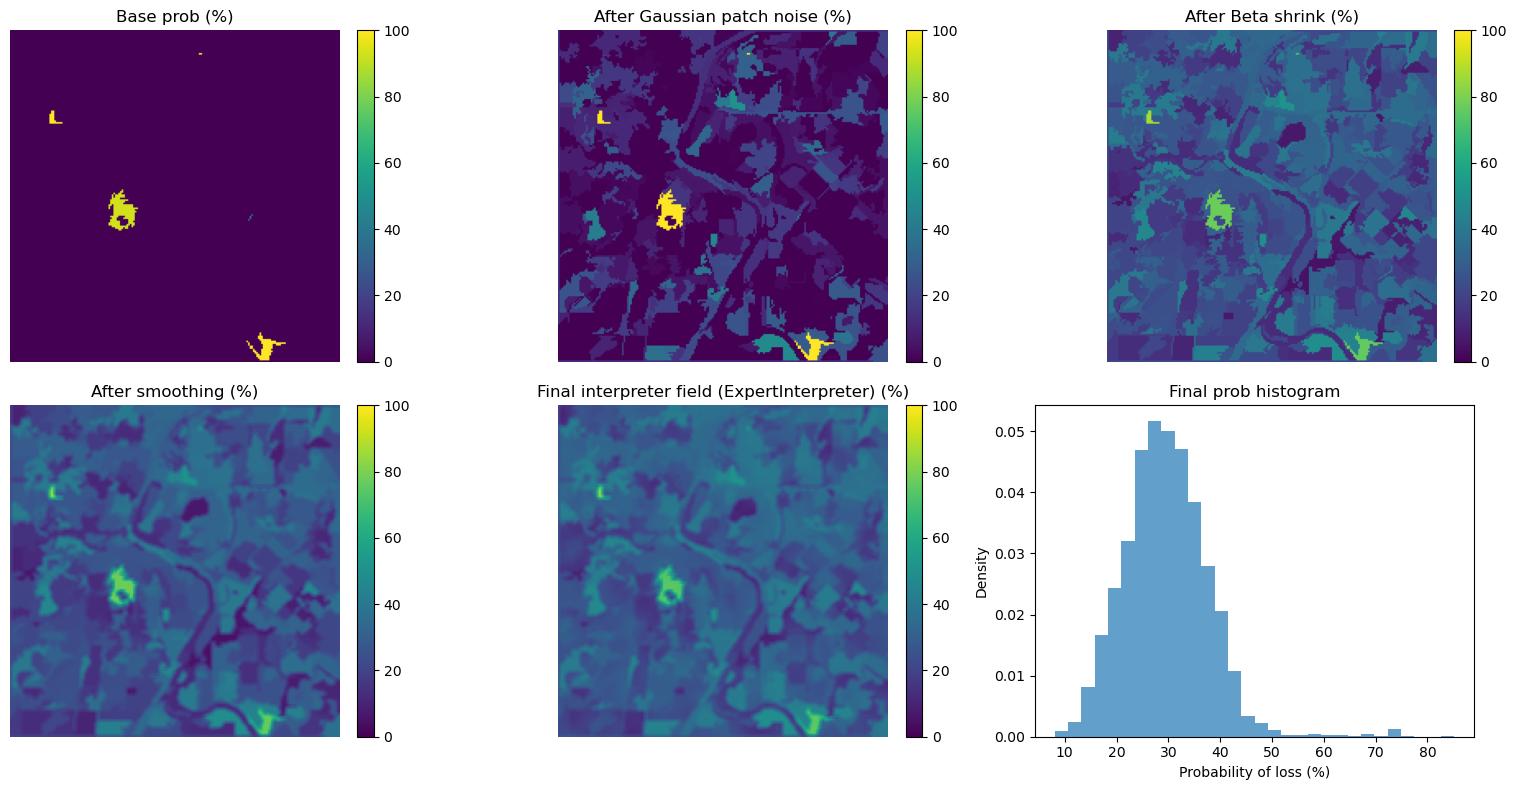

In [9]:
import interpreter_field
from interpreter_field import InterpreterField
#importlib.reload(interpreter_field)

interp = InterpreterField("ExpertInterpreter", truth=dist, config=interpreter_config)

# Final probability of loss (0–100%)
prob_loss = interp.interpreter_field

# Look at patch-level uncertainty behavior
print("Example Gaussian patch offsets (percentage points):")
print({k: v*100 for k, v in list(interp.patch_gaussian_offsets.items())[:5]})

print("Example Beta scalers (shrink towards 50%):")
print({k: v for k, v in list(interp.patch_beta_scaler.items())[:5]})

interp.plot_pipeline()